In [19]:
import pandas as pd # FOR UPLOADING THE DATA
import numpy as np
import re #  REGULAR EXPRESSION --> USED FOR DATA CLEANING (EG: PUNCTUATION, BULLETPOINTS)
import nltk
import matplotlib.pyplot as plt
from nltk.corpus import stopwords # TO REMVOE THE UNNECESSARY WORDS
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
from collections import Counter
from wordcloud import wordcloud # TO VISUALISE THE WORDS

from wordcloud import WordCloud # FOR DISPLAYING THE WORD CLOUD

#  DOWNLOAD REQUIRED NLTK FILES
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon') # (VALENCE AWARE DICTIONARY AND SENTIMENT REASONER) RULE BASED SENTIMENT ANALYSIS
nltk.download('punkt_tab') # PUNCTUATION TABS

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [20]:
# Sample customer reviews dataset
data = {
    "Review": [
        "The product quality is excellent and delivery was very fast.",
        "Very bad packaging and the item was damaged.",
        "Customer service was helpful and responsive.",
        "The delivery was delayed and support team did not respond.",
        "Amazing product. Worth the money.",
        "Poor quality product and terrible experience.",
        "Fast shipping and good packaging.",
        "The product stopped working after two days.",
        "Excellent service and great quality.",
        "Late delivery and bad customer support."
    ]
}

# Create DataFrame
df = pd.DataFrame(data)

# Display first few rows
print("Customer Reviews Dataset")
print(df.head())

Customer Reviews Dataset
                                              Review
0  The product quality is excellent and delivery ...
1       Very bad packaging and the item was damaged.
2       Customer service was helpful and responsive.
3  The delivery was delayed and support team did ...
4                  Amazing product. Worth the money.


In [21]:
stop_words=set(stopwords.words('english')) # SET IS USED BECAUSE SET HAVE PROPERTY TO NOT ALLOW DUPLICATES ...it used to remove duplicates
def Clean_text(text):  #text means one by one review of the data

  #convert to lowercase
  text=text.lower()

  # remove special characters and numbers
  text=re.sub(r'[^a-zA-Z\s]', '', text)
  print('\nspecial character removal:\n',text)

  #tokenization
  words=word_tokenize(text)
  print(words)

  #remove stopwords
  words=[word for word in words if word not in stop_words]
  print('\nwithout stop words :\n',words)

  #joins the words again
  Clean_text=" ".join(words)

  return Clean_text

# apply cleaning function
df['Cleaned_Review']=df['Review'].apply(Clean_text)

# Display cleaned reviews
print("\nCleaned Reviews:\n")
print(df['Cleaned_Review'])



special character removal:
 the product quality is excellent and delivery was very fast
['the', 'product', 'quality', 'is', 'excellent', 'and', 'delivery', 'was', 'very', 'fast']

without stop words :
 ['product', 'quality', 'excellent', 'delivery', 'fast']

special character removal:
 very bad packaging and the item was damaged
['very', 'bad', 'packaging', 'and', 'the', 'item', 'was', 'damaged']

without stop words :
 ['bad', 'packaging', 'item', 'damaged']

special character removal:
 customer service was helpful and responsive
['customer', 'service', 'was', 'helpful', 'and', 'responsive']

without stop words :
 ['customer', 'service', 'helpful', 'responsive']

special character removal:
 the delivery was delayed and support team did not respond
['the', 'delivery', 'was', 'delayed', 'and', 'support', 'team', 'did', 'not', 'respond']

without stop words :
 ['delivery', 'delayed', 'support', 'team', 'respond']

special character removal:
 amazing product worth the money
['amazing', 'p

In [22]:
# def analyze_sentiment(review):
#   score=sia.polarity_score(review)

#   compound=score['compound']

#   if compound>=0.05:
#     return "Positive"

#   elif compound

#   # Create Sentiment Analyzer object
sia = SentimentIntensityAnalyzer()

# Function to analyze sentiment
def analyze_sentiment(review):
    score = sia.polarity_scores(review)["compound"]

    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

# Apply sentiment analysis
df["Sentiment"] = df["Review"].apply(analyze_sentiment)

# Display results
print(df[["Review", "Sentiment"]])

                                              Review Sentiment
0  The product quality is excellent and delivery ...  Positive
1       Very bad packaging and the item was damaged.  Negative
2       Customer service was helpful and responsive.  Positive
3  The delivery was delayed and support team did ...  Positive
4                  Amazing product. Worth the money.  Positive
5      Poor quality product and terrible experience.  Negative
6                  Fast shipping and good packaging.  Positive
7        The product stopped working after two days.  Negative
8               Excellent service and great quality.  Positive
9            Late delivery and bad customer support.  Negative


In [23]:
all_words=" ".join(df['Cleaned_Review'])

word_list=all_words.split()

# COUNT WORD FREQUENCY

word_freq=Counter(word_list)

# DISPLAY TOP 10 KEYWORDS

print("\n Top 10 Common Keywords\n")
print(*word_freq.most_common(10),sep='\n')


 Top 10 Common Keywords

('product', 4)
('quality', 3)
('delivery', 3)
('excellent', 2)
('fast', 2)
('bad', 2)
('packaging', 2)
('customer', 2)
('service', 2)
('support', 2)


STEP 6 IDENTIFY COMMON COMPLAINTS

In [24]:
negative_reviews=df[df['Sentiment']=='Negative'] # ROW FILTER

negative_words=" ".join(negative_reviews['Cleaned_Review'])

negative_word_list=negative_words.split()

complaint_freq=Counter(negative_word_list)

print("\n Most Common Complaint Keywords")

print(*complaint_freq.most_common(10),sep='\n')


 Most Common Complaint Keywords
('bad', 2)
('product', 2)
('packaging', 1)
('item', 1)
('damaged', 1)
('poor', 1)
('quality', 1)
('terrible', 1)
('experience', 1)
('stopped', 1)


STEP 7 VISUALIZATION _ SENTIMENT COUNT

In [25]:
sentiment_counts=df['Sentiment'].value_counts() # IT WILL GIVE CATEGORY COUNT

sentiment_counts

,count
Sentiment,
Positive,6
Negative,4


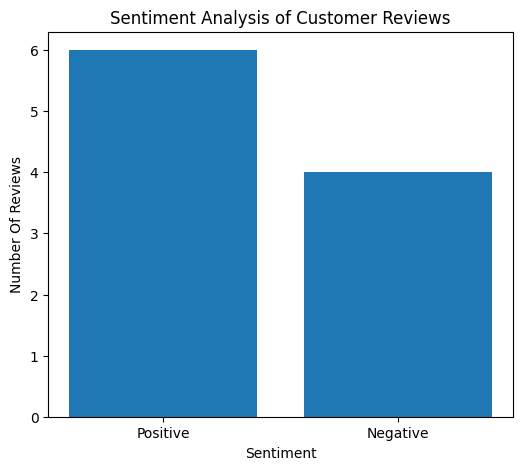

In [26]:
sentiment_counts=df['Sentiment'].value_counts() # IT WILL GIVE CATEGORY COUNT

plt.figure(figsize=(6,5))
plt.bar(sentiment_counts.index, sentiment_counts.values)

plt.title("Sentiment Analysis of Customer Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number Of Reviews")

plt.show()

GENERATE WORD CLOUD

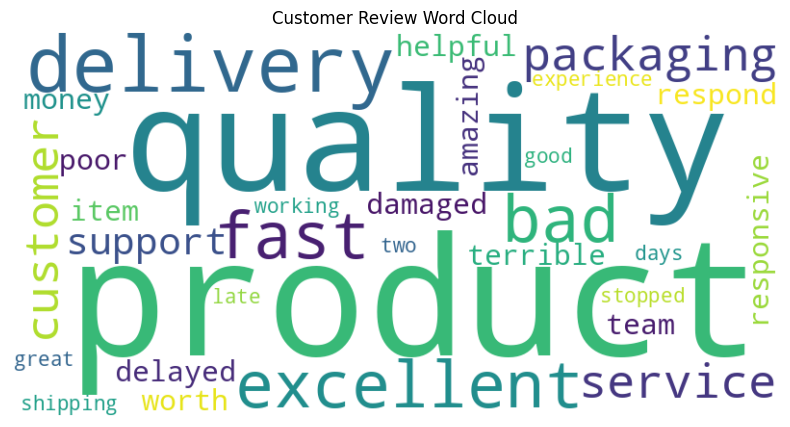

In [27]:
wordcloud=WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(all_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.title("Customer Review Word Cloud")
plt.show()

STEP 9 GENERAE BUSISINESS INSIGHTS

In [28]:
print("\nBusiness Insights")
print("---------------------")

positive_count=len(df[df['Sentiment']=='Positive'])
negative_count=len(df[df['Sentiment']=='Negative'])

print("Total Positive Reviews:", positive_count)
print("Total Negative Reviews:",negative_count)

print("\nCommon Positive Areas:")
print("- Product Quality")
print("- Fast Delivery")
print("- Good Customer Service")

print("Common Customer Complaints:")
print("- Delayed Delivery")
print("- Damaged Products")
print("- Poor Support Response")
print("- Product Malfuncion Issues")

print("\nRecommendation:")
print("- The Company Should Improve Delivery Management , ")
print("- Strengthen Packaging Quality , And Enhance Customer Support Response Time . ")


Business Insights
---------------------
Total Positive Reviews: 6
Total Negative Reviews: 4

Common Positive Areas:
- Product Quality
- Fast Delivery
- Good Customer Service
Common Customer Complaints:
- Delayed Delivery
- Damaged Products
- Poor Support Response
- Product Malfuncion Issues

Recommendation:
- The Company Should Improve Delivery Management , 
- Strengthen Packaging Quality , And Enhance Customer Support Response Time . 
